#Covered Today:

1. Introduction to Hugging Face Pipelines for Quick AI Inference
2. HuggingFace Pipelines API for Sentiment Analysis on Colab T4 GPU
3. Named Entity Recognition, Q&A, and Hugging Face Pipeline Tasks
4. Hugging Face Pipelines: Image, Audio & Diffusion Models in Colab

In [1]:
!pip install -q "transformers<5"

In [2]:
# we start by importing the same libraries, loading the secret and login in
# huggingface
from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [3]:
# Now, we check if we are connected to a GPU and confirm if it is Tesla T4
gpu_info = !nvidia-smi
gpu_info = "\n".join(gpu_info)

if gpu_info.find('failed') >= 0:
  print("Not connected to a GPU")
else:
  print(gpu_info)
  if gpu_info.find("Tesla T4") >= 0:
    print("Success - Connected to a T4")
  else:
    print("Not connected to a T4")

Mon Aug 24 10:17:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             15W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Now, as per the forked file, Ed is using older versions of 'datasets==3.6.0 and 'transformers==4.57.6' and the latest versions are transformers: 5.15.0 and diffusers: 0.39.0, we use these new ones. On facing any errors, we do a proper non-ai assisted search and correct our code. In case of inability to solve without AI, we move to AI assistance.

Now, there are two types of huggingface libraries. We can call them the higher level and lower level libraries, similar to high and low level languages. High level huggingface libraries are basically called 'Pipelines' and low level libraries are 'Tokenizers and Models'.

Now, when do we use either of these depends upon the task at hand.

Pipelines are used when the model has already been trained, and we want to use two lines of code to achieve a business objective, we use Pipelines. These are further categorized as: Sentiment Analysis, Classifier, Named Entity recognition, Question Answering, Summarizing and Translation.




In [4]:
# Next up are the imports:

import torch
# this is pytorch, the famous python library, used by data scientists the world over to train neural networks. It helps a user to use the power of GPUs.


from transformers import pipeline
# transformer library by huggingface provides everything that one needs for inference or training with existing pretrained models. Pipeline is a part of transformers and is a an API to be used for inference.


from diffusers import DiffusionPipeline
# diffusers is a library of pretrained models used for creation of images, audio and video.
# DiffusionPipeline is a part of diffusers and is used to infer images, audio and video easily.


from datasets import load_dataset
# Datasets is a library for easily accessing and sharing AI datasets for Audio, Computer Vision, and Natural Language Processing (NLP) tasks. The load_dataset is used to load the datasets present in the hub and which we need to use, in the memory.


import soundfile as sf
# a python library that can read and write audio files.


from IPython.display import Audio

Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [ ]:
# Now, we will be using pipelines to generate context such as text, images and audio similar to what we did yesterday.
# Now, running a pipeline is very simple, we do my_pipeline = pipeline(task to do, model=xx, device=xx) followed by result = my_pipeline(input)

# while creating a pipeline, we need to describe the task we are doing and model and device are optional. We can specify an open source model to do our task or we can skip it, then huggingface will auto assign one.

# For device, we need to specify if we want to use a GPU. Now, since we are using nvidia GPUs in colab, we need to specify device as cuda, which is a nvidia technology similar to c++ which allows us to run parralel tasks on GPUs. If we try to use locally on mac - silicon, then we use mps. Once, a pipeline is created, then we can call it as many times it is needed.

# we start by creating and running our first pipeline now. We will be using sentiment analaysis using an open source model.

my_simple_sentiment_analyzer = pipeline('sentiment-analysis', device="cuda")
result = my_simple_sentiment_analyzer("I am super excited to be on the way to LLM mastery.")
print(result)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.9991791844367981}]


In [ ]:
# this was the first task that ran on the GPU that we wrote on our own. Also, we can now run the same pipeline.
result = my_simple_sentiment_analyzer("I should be more excited to be on the way to LLM mastery. This is awesome.")
print(result)

[{'label': 'POSITIVE', 'score': 0.9997820258140564}]


In [ ]:
# now, we create a new one and specify model also.
new_sentiment = pipeline("sentiment-analysis", model='tabularisai/multilingual-sentiment-analysis', device='cuda')
result = new_sentiment("I should be more excited to be on the way to LLM mastery. This is awesome.")
print(result)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'Negative', 'score': 0.5200813412666321}]


In [ ]:
new_sentiment_2 = pipeline("sentiment-analysis", model="finiteautomata/bertweet-base-sentiment-analysis", device="cuda")
result = new_sentiment_2("I should be more excited to be on the way to LLM mastery. This is awesome.")
print(result)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


[{'label': 'POS', 'score': 0.9929042458534241}]


In [ ]:
# we run these models on other input also, since there is a lot of variation in the scores.
result = my_simple_sentiment_analyzer("This is amazing, having the ability to run LLMs locally, like this.")
print(result)
result = new_sentiment("This is amazing, having the ability to run LLMs locally, like this.")
print(result)
result = new_sentiment_2("This is amazing, having the ability to run LLMs locally, like this.")
print(result)

[{'label': 'POSITIVE', 'score': 0.9998737573623657}]
[{'label': 'Positive', 'score': 0.5283348560333252}]
[{'label': 'POS', 'score': 0.9874979257583618}]


In [ ]:
# The following is not in the course, we are doing this basis our research. All models have multiple rating categories, like positive and negative. And in the results, they only show which they consider is of the highest probability. We can also check what was the probablity given to each of the category by adding an argument top_k=None while giving the input, let's try it out.
result = my_simple_sentiment_analyzer("This is amazing, having the ability to run LLMs locally, like this.", top_k=None)
print(result)
result = new_sentiment("This is amazing, having the ability to run LLMs locally, like this.", top_k=None)
print(result)
result = new_sentiment_2("This is amazing, having the ability to run LLMs locally, like this.", top_k=None)
print(result)

[{'label': 'POSITIVE', 'score': 0.9998737573623657}, {'label': 'NEGATIVE', 'score': 0.00012618581240531057}]
[{'label': 'Positive', 'score': 0.5283348560333252}, {'label': 'Very Positive', 'score': 0.37124428153038025}, {'label': 'Neutral', 'score': 0.05177395045757294}, {'label': 'Negative', 'score': 0.02836959809064865}, {'label': 'Very Negative', 'score': 0.020277319476008415}]
[{'label': 'POS', 'score': 0.9874979257583618}, {'label': 'NEU', 'score': 0.01078568771481514}, {'label': 'NEG', 'score': 0.0017163855955004692}]


As we can see from the above results, while we were comparing the scores, they were not the same thing in the first place. Each of the model has different categories and accordingly they have given the scores.

In [ ]:
# next we move to named entity recognition. This is a natural language processing technique, where by using LLMs we can categorise various entities in unstructured text into predecided categories. We will be using pipelines for for this also. The task is 'ner'
ner = pipeline('ner', device="cuda")
result = ner("My name is Sumit and I live in delhi. I am learning AI engineering using ED Donner's courses. Right now, I am using colab to run free Tesla T4 GPUs.")
print(result)

[transformers] No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.33GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

[{'entity': 'I-PER', 'score': np.float32(0.99907637), 'index': 4, 'word': 'Su', 'start': 11, 'end': 13}, {'entity': 'I-PER', 'score': np.float32(0.99859864), 'index': 5, 'word': '##mit', 'start': 13, 'end': 16}, {'entity': 'I-LOC', 'score': np.float32(0.9080047), 'index': 10, 'word': 'del', 'start': 31, 'end': 34}, {'entity': 'I-LOC', 'score': np.float32(0.97590953), 'index': 11, 'word': '##hi', 'start': 34, 'end': 36}, {'entity': 'I-MISC', 'score': np.float32(0.4696038), 'index': 16, 'word': 'AI', 'start': 52, 'end': 54}, {'entity': 'I-ORG', 'score': np.float32(0.98730963), 'index': 19, 'word': 'E', 'start': 73, 'end': 74}, {'entity': 'I-ORG', 'score': np.float32(0.9166856), 'index': 20, 'word': '##D', 'start': 74, 'end': 75}, {'entity': 'I-ORG', 'score': np.float32(0.93029225), 'index': 21, 'word': 'Don', 'start': 76, 'end': 79}, {'entity': 'I-ORG', 'score': np.float32(0.9793432), 'index': 22, 'word': '##ner', 'start': 79, 'end': 82}, {'entity': 'I-MISC', 'score': np.float32(0.992356

In [ ]:
# As we can see, we got a list of dicts as our result, therefore we can iterate over this list to get a better tabular format.
for entity in result:
  print(entity)

{'entity': 'I-PER', 'score': np.float32(0.99907637), 'index': 4, 'word': 'Su', 'start': 11, 'end': 13}
{'entity': 'I-PER', 'score': np.float32(0.99859864), 'index': 5, 'word': '##mit', 'start': 13, 'end': 16}
{'entity': 'I-LOC', 'score': np.float32(0.9080047), 'index': 10, 'word': 'del', 'start': 31, 'end': 34}
{'entity': 'I-LOC', 'score': np.float32(0.97590953), 'index': 11, 'word': '##hi', 'start': 34, 'end': 36}
{'entity': 'I-MISC', 'score': np.float32(0.4696038), 'index': 16, 'word': 'AI', 'start': 52, 'end': 54}
{'entity': 'I-ORG', 'score': np.float32(0.98730963), 'index': 19, 'word': 'E', 'start': 73, 'end': 74}
{'entity': 'I-ORG', 'score': np.float32(0.9166856), 'index': 20, 'word': '##D', 'start': 74, 'end': 75}
{'entity': 'I-ORG', 'score': np.float32(0.93029225), 'index': 21, 'word': 'Don', 'start': 76, 'end': 79}
{'entity': 'I-ORG', 'score': np.float32(0.9793432), 'index': 22, 'word': '##ner', 'start': 79, 'end': 82}
{'entity': 'I-MISC', 'score': np.float32(0.99235654), 'inde

In [ ]:
ner = pipeline('ner', model="dslim/bert-base-NER", device="cuda")
result = ner("My name is Sumit and I live in delhi. I am learning AI engineering using ED Donner's courses. Right now, I am using colab to run free Tesla T4 GPUs.")
for entity in result:
  print(entity)

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  433MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

{'entity': 'B-PER', 'score': np.float32(0.99871266), 'index': 4, 'word': 'Su', 'start': 11, 'end': 13}
{'entity': 'B-PER', 'score': np.float32(0.90173227), 'index': 5, 'word': '##mit', 'start': 13, 'end': 16}
{'entity': 'B-LOC', 'score': np.float32(0.98541427), 'index': 10, 'word': 'del', 'start': 31, 'end': 34}
{'entity': 'I-LOC', 'score': np.float32(0.77284217), 'index': 11, 'word': '##hi', 'start': 34, 'end': 36}
{'entity': 'B-MISC', 'score': np.float32(0.99073), 'index': 16, 'word': 'AI', 'start': 52, 'end': 54}
{'entity': 'B-ORG', 'score': np.float32(0.56467646), 'index': 19, 'word': 'E', 'start': 73, 'end': 74}
{'entity': 'B-PER', 'score': np.float32(0.5136852), 'index': 20, 'word': '##D', 'start': 74, 'end': 75}
{'entity': 'I-PER', 'score': np.float32(0.9598073), 'index': 21, 'word': 'Don', 'start': 76, 'end': 79}
{'entity': 'B-MISC', 'score': np.float32(0.99615496), 'index': 39, 'word': 'Te', 'start': 134, 'end': 136}
{'entity': 'I-MISC', 'score': np.float32(0.9746488), 'index'

In [ ]:
# here, we can see that text is classified into either person, location, miscellaneous, organization etc.
# next up is question-answering, this is similar to chat completion, however, here, we ask a question and give context and then the question is answered from within the context.

question = "What is RAG?"
context = "Retrieval-Augmented Generation (RAG) is an AI architecture that enhances Large Language Models by fetching relevant data from external knowledge bases before generating a response. Introduced by Meta AI in 2020, RAG combines an information retrieval component with a generative neural network. Instead of relying solely on static training weights, the system converts external documents into vector embeddings stored in a vector database. When a user asks a question, the retriever fetches the most semantically similar text chunks, allowing the language model to provide grounded, up-to-date answers and significantly reduce hallucinations without full fine-tuning."
q_and_a = pipeline("question-answering", device="cuda")
result = q_and_a(question = question, context = context)
print(result)

KeyError: "Unknown task question-answering, available tasks are ['any-to-any', 'audio-classification', 'automatic-speech-recognition', 'depth-estimation', 'document-question-answering', 'feature-extraction', 'fill-mask', 'image-classification', 'image-feature-extraction', 'image-segmentation', 'image-text-to-text', 'keypoint-matching', 'mask-generation', 'ner', 'object-detection', 'sentiment-analysis', 'table-question-answering', 'text-classification', 'text-generation', 'text-to-audio', 'text-to-speech', 'token-classification', 'video-classification', 'zero-shot-audio-classification', 'zero-shot-classification', 'zero-shot-image-classification', 'zero-shot-object-detection']"

In [6]:
# we received the above error, and found out that question-answering is not available in transformers version 5 or above, hence, we will have to now, !pip install -q "transformers<5", doing this at the top of the file. Post this, we need to restart the session.

# Now, we try to run the above code again.
question = "What does RAG do?"
context = "Retrieval-Augmented Generation (RAG) is an AI architecture that enhances Large Language Models by fetching relevant data from external knowledge bases before generating a response. Introduced by Meta AI in 2020, RAG combines an information retrieval component with a generative neural network. Instead of relying solely on static training weights, the system converts external documents into vector embeddings stored in a vector database. When a user asks a question, the retriever fetches the most semantically similar text chunks, allowing the language model to provide grounded, up-to-date answers and significantly reduce hallucinations without full fine-tuning."
q_and_a = pipeline("question-answering", device="cuda")
result = q_and_a(question = question, context = context)
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda


{'score': 0.2875620424747467, 'start': 64, 'end': 94, 'answer': 'enhances Large Language Models'}


In [7]:
# next up is summarizer, which when given text, summarizes it. We can define minimum and maximum words for it. while rest almost remains the same.

text_summarizer = pipeline("summarization", device='cuda')
result = text_summarizer(context, max_length=50, min_length=25)
print(result)

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


[{'summary_text': ' Retrieval-Augmented Generation (RAG) combines an information retrieval component with a generative neural network . The system converts external documents into vector embeddings stored in a vector database .'}]


In [13]:
# next we move to translation, we need to specify the language in the task
translator = pipeline("translation_en_to_fr", device='cuda')
result = translator(context)
print(result)

No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda


[{'translation_text': "Retrieval-Augmented Generation (RAG) est une architecture AI qui améliore les grands modèles linguistiques en extrayant des données pertinentes des bases de connaissances externes avant de générer une réponse. Mise en place par Meta AI en 2020, RAG combine une composante de récupération de l'information et un réseau neural générateur. Au lieu de s'appuyer uniquement sur des poids d'entraînement statiques, le système convert"}]


In [14]:
# while a default model is provided for english to french, nothing is provided for english to hindi, we try this by specifying a model.

translator = pipeline("translation_en_to_fr", model='Helsinki-NLP/opus-mt-en-hi', device='cuda')
result = translator(context)
print(result)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/306M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/812k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.13/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cuda


[{'translation_text': 'एक एआई-जी (जी. ए. ए.) का उपयोग करने से पहले विशिष्ट भाषा मॉडलों को बाहरी ज्ञान आधार से प्राप्त करने से पहले उपयोगी भाषा मॉडलों को विकसित करता है.'}]


In [15]:
# since, this comes as a list with dicts, we can also return the following:

print(result[0])

{'translation_text': 'एक एआई-जी (जी. ए. ए.) का उपयोग करने से पहले विशिष्ट भाषा मॉडलों को बाहरी ज्ञान आधार से प्राप्त करने से पहले उपयोगी भाषा मॉडलों को विकसित करता है.'}


In [16]:
# or further

print(result[0]['translation_text'])

एक एआई-जी (जी. ए. ए.) का उपयोग करने से पहले विशिष्ट भाषा मॉडलों को बाहरी ज्ञान आधार से प्राप्त करने से पहले उपयोगी भाषा मॉडलों को विकसित करता है.


In [17]:
# and also
print(result[0].get("translation_text"))

एक एआई-जी (जी. ए. ए.) का उपयोग करने से पहले विशिष्ट भाषा मॉडलों को बाहरी ज्ञान आधार से प्राप्त करने से पहले उपयोगी भाषा मॉडलों को विकसित करता है.


In [8]:
# next up is text classification in categories defined by us. task for this is zero shot classification, where we tell the system, that I will be giving you some sentences, and I will give you some buckets and put the sentences in those bucket.

text_list = ["I was charged twice on my credit card for this month's subscription renewal.", "The mobile app crashes immediately every time I try to export a PDF report.", "Can you let me know if there's a volume discount available if our team switches to an annual enterprise tier?", "I forgot my password and no longer have access to the original recovery email address.", "The table values in the dashboard are failing to sync with our PostgreSQL database after the latest update."]
candidate_labels = ["Billing & Invoicing", "Technical Issue", "Sales & Upgrades", "Account & Access"]
text_classification = pipeline("zero-shot-classification", device='cuda')

for text in text_list:

  print(text_classification(text, candidate_labels=candidate_labels))


No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda


{'sequence': "I was charged twice on my credit card for this month's subscription renewal.", 'labels': ['Billing & Invoicing', 'Account & Access', 'Technical Issue', 'Sales & Upgrades'], 'scores': [0.36173492670059204, 0.3282819092273712, 0.18215665221214294, 0.12782643735408783]}
{'sequence': 'The mobile app crashes immediately every time I try to export a PDF report.', 'labels': ['Technical Issue', 'Account & Access', 'Sales & Upgrades', 'Billing & Invoicing'], 'scores': [0.7929689884185791, 0.12598326802253723, 0.04239201545715332, 0.03865572437644005]}
{'sequence': "Can you let me know if there's a volume discount available if our team switches to an annual enterprise tier?", 'labels': ['Account & Access', 'Sales & Upgrades', 'Billing & Invoicing', 'Technical Issue'], 'scores': [0.36026519536972046, 0.22893597185611725, 0.22305844724178314, 0.18774037063121796]}
{'sequence': 'I forgot my password and no longer have access to the original recovery email address.', 'labels': ['Accoun

In [9]:
# here the categories are overlapping, hence results do not come out as expected. we now work with non overlapping categories.
text_list = ["The striker scored a hat-trick in the second half to lead the team to a 3-1 victory in the final match.", "Parliament passed the new bipartisan healthcare reform bill following three days of intense floor debates.", "The semiconductor startup unveiled a 2-nanometer processor architecture that cuts power consumption by 40%.", "The veteran point guard was traded ahead of the deadline to bolster the franchise's championship roster.", "The electoral commission announced nationwide dates for the upcoming general election and published voter registration rules."]
candidate_labels = ["Sports", "Politics", "Technology"]


for text in text_list:
  print(text_classification(text, candidate_labels))

{'sequence': 'The striker scored a hat-trick in the second half to lead the team to a 3-1 victory in the final match.', 'labels': ['Sports', 'Technology', 'Politics'], 'scores': [0.8152846097946167, 0.1478307843208313, 0.03688466176390648]}
{'sequence': 'Parliament passed the new bipartisan healthcare reform bill following three days of intense floor debates.', 'labels': ['Politics', 'Technology', 'Sports'], 'scores': [0.9546761512756348, 0.02556733600795269, 0.019756551831960678]}
{'sequence': 'The semiconductor startup unveiled a 2-nanometer processor architecture that cuts power consumption by 40%.', 'labels': ['Technology', 'Sports', 'Politics'], 'scores': [0.9495820999145508, 0.03778412193059921, 0.012633755803108215]}
{'sequence': "The veteran point guard was traded ahead of the deadline to bolster the franchise's championship roster.", 'labels': ['Sports', 'Technology', 'Politics'], 'scores': [0.7649495601654053, 0.16801020503044128, 0.06704027205705643]}
{'sequence': 'The elect

In [13]:
# this one worked great, next up, we move to text generation:
generate_text = pipeline("text-generation", device="cuda")
result = generate_text("Yesterday, I went to the zoo in New Delhi and")
print(result[0]["generated_text"])

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Yesterday, I went to the zoo in New Delhi and met my dog. She was doing well and I immediately contacted the zoo. She was just so happy. She also brought me a bottle of milk. I had a huge grin on my face.

I've been so grateful to the zoo for giving me this gift. I hope this will be the last time I see my pet again.


In [5]:
# in the last one, huggingface picked up gpt2 to do the task. we know, gpt2 is known for throwing out gibberish. Now, we move to generation of non text content such as images and audio. However, to display the images, we need to import display from IPython.display
from IPython.display import display

# also, since for images we use diffusion models, we use a different pipeline as compared to what we were doing so far, since, we will be converting text to image, we will be using a pipeline that actually works on this
from diffusers import AutoPipelineForText2Image

# and we also need torch, which we have already imported above

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

safety_checker/model.fp16.safetensors:   0%|          | 0.00/608M [00:00<?, ?B/s]

text_encoder/model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

Keyword arguments {'dtype': torch.float16} are not expected by StableDiffusionPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

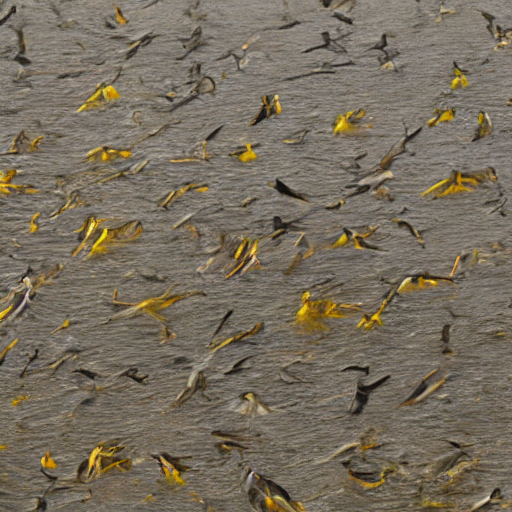

In [7]:
# now, we define a pipe
pipe = AutoPipelineForText2Image.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", dtype=torch.float16, variant='fp16')
prompt = "birds flying in the sky"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0).images[0]
display(image)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.
There are modules in AutoencoderKL that should be kept in float32: []. Casting directly with `to()` can lead to inconsistent results; set `torch_dtype` in `from_pretrained()` instead to keep these modules in float32.


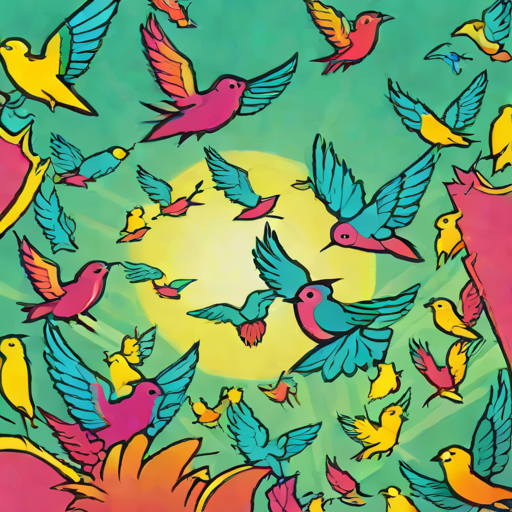

In [8]:
# poor results since we used a very small model, bigger models were filling the ram(because I forgot to send the image to CUDA and the above image has been created by using the CPU and not GPU.) and the session was being disconnected again and again. Trying one more time

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant='fp16')
pipe.to("cuda")
prompt = "birds flying in the sky, in vibrant pop-art style"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)

In [ ]:
# Now the results came out better. Similarly we can generate audio using hugging face models. A list of all the available pipelines can be found here:
https://huggingface.co/docs/transformers/main_classes/pipelines